<a href="https://colab.research.google.com/github/swethaukkarde/Neural-networks-and-deep-learning/blob/main/Exp_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


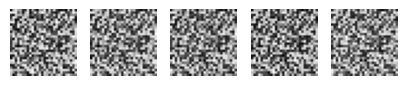

In [1]:
# Problem Statement:
# A digital art company wants to generate new handwritten-style fonts.
# Build a GAN that generates MNIST-style digits and analyze how the
# generator and discriminator improve through competition.

import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Step 1: Load Dataset (Reduced)
# -------------------------------
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Reduce dataset (faster training)
x_train = x_train[:5000]

x_train = x_train / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)

# -------------------------------
# Step 2: Generator
# -------------------------------
generator = tf.keras.Sequential([
    layers.Dense(64, activation='relu', input_dim=100),
    layers.Dense(784, activation='sigmoid'),
    layers.Reshape((28,28,1))
])

# -------------------------------
# Step 3: Discriminator
# -------------------------------
discriminator = tf.keras.Sequential([
    layers.Flatten(input_shape=(28,28,1)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

discriminator.compile(optimizer='adam', loss='binary_crossentropy')

# -------------------------------
# Step 4: GAN
# -------------------------------
discriminator.trainable = False

gan = tf.keras.Sequential([generator, discriminator])
gan.compile(optimizer='adam', loss='binary_crossentropy')

# -------------------------------
# Step 5: Train (Reduced epochs)
# -------------------------------
epochs = 300
batch_size = 32

for epoch in range(epochs):
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real = x_train[idx]

    noise = np.random.normal(0,1,(batch_size,100))
    fake = generator.predict(noise, verbose=0)

    discriminator.train_on_batch(real, np.ones((batch_size,1)))
    discriminator.train_on_batch(fake, np.zeros((batch_size,1)))

    noise = np.random.normal(0,1,(batch_size,100))
    gan.train_on_batch(noise, np.ones((batch_size,1)))

# -------------------------------
# Step 6: Generate Images
# -------------------------------
noise = np.random.normal(0,1,(5,100))
images = generator.predict(noise)

plt.figure(figsize=(5,1))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i].reshape(28,28), cmap='gray')
    plt.axis('off')
plt.show()